## Kaggle – DataTops®
Tu profe ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Métrica: 
El error cuadrático medio (RMSE, por sus siglas en inglés) es una medida de la desviación estándar de los residuos (errores de predicción). Los residuos representan la diferencia entre los valores observados y los valores predichos por el modelo. El RMSE indica qué tan dispersos están estos errores: cuanto menor es el RMSE, más cercanas están las predicciones a los valores reales. En otras palabras, el RMSE mide qué tan bien se ajusta la línea de regresión a los datos.


$$ RMSE = \sqrt{\frac{1}{n}\Sigma_{i=1}^{n}{\Big(\frac{d_i -f_i}{\sigma_i}\Big)^2}}$$


In [56]:
# Esta es la métrica con la que nos vamos a evaluar intento 3

## 1. Librerías

In [57]:
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import urllib.request

## 2. Datos

In [58]:
# Para que funcione necesitas bajarte los archivos de datos de Kaggle 
df = pd.read_csv("./data/train.csv")

### 2.1 Exploración de los datos

In [59]:
df.info() # No hay valores nulos.
# 3 columnas son numéricas y 10 de texto

<class 'pandas.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         912 non-null    int64  
 1   Company           912 non-null    str    
 2   Product           912 non-null    str    
 3   TypeName          912 non-null    str    
 4   Inches            912 non-null    float64
 5   ScreenResolution  912 non-null    str    
 6   Cpu               912 non-null    str    
 7   Ram               912 non-null    str    
 8   Memory            912 non-null    str    
 9   Gpu               912 non-null    str    
 10  OpSys             912 non-null    str    
 11  Weight            912 non-null    str    
 12  Price_in_euros    912 non-null    float64
dtypes: float64(2), int64(1), str(10)
memory usage: 92.8 KB


In [60]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
0,755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
1,618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
2,909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
3,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
4,286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00


In [61]:
df.tail()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
907,28,Dell,Inspiron 5570,Notebook,15.6,Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,AMD Radeon 530,Windows 10,2.2kg,800.00
908,1160,HP,Spectre Pro,2 in 1 Convertible,13.3,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.48kg,1629.00
909,78,Lenovo,IdeaPad 320-15IKBN,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,2TB HDD,Intel HD Graphics 620,No OS,2.2kg,519.00
910,23,HP,255 G6,Notebook,15.6,1366x768,AMD E-Series E2-9000e 1.5GHz,4GB,500GB HDD,AMD Radeon R2,No OS,1.86kg,258.00
911,229,Dell,Alienware 17,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,4.42kg,2456.34


In [62]:
df.describe() 

,laptop_ID,Inches,Price_in_euros
count,912.000000,912.000000,912.000000
mean,650.312500,14.981579,1111.724090
std,382.727748,1.436719,687.959172
min,2.000000,10.100000,174.000000
25%,324.750000,14.000000,589.000000
50%,636.500000,15.600000,978.000000
75%,982.250000,15.600000,1483.942500
max,1320.000000,18.400000,6099.000000


## Punto de partida
Objetivo: Predecir el precio de un portátil (Price_in_euros) basándondonos en las características (RAM, peso, disco...)  

Fases: Entrenamiento (Estudio) le damos al modelo el dataset con las carácterísticas + precio y el modelo busca las "reglas" matemáticas; y predicción (Kaggle) le damos el archivo nuevo, el del test, donde no sabe el precio. Este modelo usará las reglas que ha aprendido para adivinar cuánto vale cada uno de los portátiles.

## Primer paso: EDA
Problema: el dataset original viene "sucio" y en idioma humano, lo tengo portanto que pasar a idioma máquina, es decir a columnas numéricas todo lo que me sale como variables tipo string.

In [63]:
# Limpieza de texto en números: Ram y Weight
if 'Ram' in df.columns and df['Ram'].dtype == 'str':
    df['Ram'] = df['Ram'].str.replace('GB', '', case=False).astype(int)
if 'Weight' in df.columns and df['Weight'].dtype == 'str':
    df['Weight'] = df['Weight'].str.replace('kg', '', case=False).astype(float)

In [64]:
# Feature engineering para la pantalla, variable: ScreenResolution)
# Si estáctil, (Touchscreen),1; o no lo es, 0.
if 'ScreenResolution' in df.columns:
    df['Touchscreen'] = df['ScreenResolution'].str.contains('Touchscreen', case=False).astype(int)
    
    # Extraemos la resolución con expresiones regulares
    df['Resolution_Width'] = df['ScreenResolution'].str.extract(r'(\d+)x\d+').astype(float)
    df['Resolution_Height'] = df['ScreenResolution'].str.extract(r'\d+x(\d+)').astype(float)
    
    # Una vez extraída la info útil, borro la columna original de texto
    df.drop(columns=['ScreenResolution'], inplace=True)

In [65]:
# Feature engineering para el procesador, variable: Cpu)
# Extraemos la velocidad en GHz como un número decimal
if 'Cpu' in df.columns:
    df['Cpu_Speed_GHz'] = df['Cpu'].str.extract(r'(\d+\.?\d*)GHz').astype(float)
    
    # Extraemos la marca principal del procesador (Intel, AMD, Samsung)
    df['Cpu_Brand'] = df['Cpu'].apply(lambda x: x.split()[0])
    
    df.drop(columns=['Cpu'], inplace=True)

In [66]:
# Feature engineering para el almacenamiento, variable: Memory)
# Clasifico si tiene SSD, HDD o Flash
if 'Memory' in df.columns:
    df['Memory_SSD_GB'] = df['Memory'].str.extract(r'(\d+)GB\s*SSD|(\d+)TB\s*SSD').apply(
        lambda x: int(x[0]) if pd.notnull(x[0]) else (int(x[1])*1024 if pd.notnull(x[1]) else 0), axis=1
    )
    df['Memory_HDD_GB'] = df['Memory'].str.extract(r'(\d+)GB\s*HDD|(\d+)TB\s*HDD').apply(
        lambda x: int(x[0]) if pd.notnull(x[0]) else (int(x[1])*1024 if pd.notnull(x[1]) else 0), axis=1
    )
    
    df.drop(columns=['Memory'], inplace=True)

In [67]:
# simplifico la variable de la gráfica: Gpu)
# Dejo solo con la marca => Intel, Nvidia, AMD
if 'Gpu' in df.columns:
    df['Gpu_Brand'] = df['Gpu'].apply(lambda x: x.split()[0])
    df.drop(columns=['Gpu'], inplace=True)

In [68]:
# Transformación de variables categóricas restantes a números (el encoding)
# Columnas => Company, TypeName, OpSys, Cpu_Brand, Gpu_Brand
categorical_cols = ['Company', 'TypeName', 'OpSys', 'Cpu_Brand', 'Gpu_Brand']

# Con el One-Hot Encoding las vamos a convertir también en columnas de 0 y 1
# Tngo que aplicarlo esto tanto al conjunto de train como al de test!!
# o hacerlo antes de dividirlos >>para que tengan exactamente las mismas columnas<<
df = pd.get_dummies(df, columns=[col for col in categorical_cols if col in df.columns], drop_first=True)

In [69]:
# Comprobación final... 
df.info()
# 

<class 'pandas.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 46 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   laptop_ID             912 non-null    int64  
 1   Product               912 non-null    str    
 2   Inches                912 non-null    float64
 3   Ram                   912 non-null    int64  
 4   Weight                912 non-null    float64
 5   Price_in_euros        912 non-null    float64
 6   Touchscreen           912 non-null    int64  
 7   Resolution_Width      912 non-null    float64
 8   Resolution_Height     912 non-null    float64
 9   Cpu_Speed_GHz         912 non-null    float64
 10  Memory_SSD_GB         912 non-null    int64  
 11  Memory_HDD_GB         912 non-null    int64  
 12  Company_Apple         912 non-null    bool   
 13  Company_Asus          912 non-null    bool   
 14  Company_Chuwi         912 non-null    bool   
 15  Company_Dell          912 non-null

Me queda una columna str, que es 'product', que contiene el modelo exacto del portátil. Considero que la información que afecta al target ya la tenemos en el resto de columnas, las características. Por lo tanto, voy a eliminar Product y laptop_ID, que de por sí no aportan nada al precio:

In [70]:
# Elimino esas columnas
df.drop(columns=['Product', 'laptop_ID'], inplace=True, errors='ignore')

# Vuelta a comprobar... Y me quedo con estas 43 columnas
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 44 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Inches                912 non-null    float64
 1   Ram                   912 non-null    int64  
 2   Weight                912 non-null    float64
 3   Price_in_euros        912 non-null    float64
 4   Touchscreen           912 non-null    int64  
 5   Resolution_Width      912 non-null    float64
 6   Resolution_Height     912 non-null    float64
 7   Cpu_Speed_GHz         912 non-null    float64
 8   Memory_SSD_GB         912 non-null    int64  
 9   Memory_HDD_GB         912 non-null    int64  
 10  Company_Apple         912 non-null    bool   
 11  Company_Asus          912 non-null    bool   
 12  Company_Chuwi         912 non-null    bool   
 13  Company_Dell          912 non-null    bool   
 14  Company_Fujitsu       912 non-null    bool   
 15  Company_Google        912 non-null

## Conclusión 
- He quitado las unidades (GB, kg) para que Pandas reconozca la RAM y el Peso como los números reales con los que el modelo puede calcular diferencias.
- Además he siplificado texto complejo, ya que había columnas con demasiada información junta. (Como la resolución de pantalla y la memoria, que ahora están separadas en columnas limpias de píxeles, de GB de SSD y GB de HDD).)
- Por último, he aplicado One-Hot Encoding, para codificar en columnas binarias (0 y 1) las marcas y y los tipos de ordenador, que eran str puros.

### 2.3 Definir X e y

Ahora que las columnas son 100% numéricas, debemos separar X (las características): todas las columnas menos el precio, e y (el objetivo o target) la columna Price_in_euros,lo que queremos predecir.

In [71]:
X = df.drop(['Price_in_euros'], axis=1) # Todas las columnas menos el target (preguntas)
y = df['Price_in_euros'].copy() # SOLO el target (respuesta correcta)
X.shape # Esta es la forma de toooodas las características (me lo dan hecho)

(912, 43)

In [72]:
X.shape

(912, 43)

In [73]:
y.shape # ...y esta la forma del target, que solo tiene que ser una, es decir que tiene las 912 filas pero una sola dimensión: el precio

(912,)

### 2.4 Dividir X_train, X_test, y_train, y_test

Voy a dividir el dataset X e y original de 912 ordenadores en dos partes:
- X_train e y_train (el entrenamiento, un 80%): con lo que el modelo busca las reglas matemáticas.
- X_test e y_test (el simulacro, un 20%): le voy a dar al modelo esta parte de X (X_test) sin decirle los precios (y) para que adivine él los precios. Después voy a comparar sus predicciones con y_test (los precios reales que no le había dado) para ver qué nota saca mi nodelo (el error RMSE) antes de mandárselo a Kaggle.

In [74]:
# Divido, como he dicho, el dataset en 80% para entrenar y 20% para testear
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)
# test_size=0.20 => significa que dejo el 20% pra ese simulacro
# random_state=42 => el seed que sirve para que la división aleatoria sea siempre la misma cada vez que le doy al Play y no me cambie los números.

In [75]:
X_train

,Inches,Ram,Weight,Touchscreen,Resolution_Width,Resolution_Height,Cpu_Speed_GHz,Memory_SSD_GB,Memory_HDD_GB,Company_Apple,...,OpSys_Linux,OpSys_Mac OS X,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS,Cpu_Brand_Intel,Gpu_Brand_Intel,Gpu_Brand_Nvidia
25,17.3,8,3.00,0,1920.0,1080.0,2.6,0,1024,False,...,False,False,False,False,False,True,False,True,False,False
84,15.6,16,2.56,0,1920.0,1080.0,2.8,512,0,False,...,False,False,False,True,False,False,False,True,False,True
10,13.3,8,1.37,0,2560.0,1600.0,2.9,512,0,True,...,False,False,False,False,False,False,True,True,True,False
342,14.0,4,1.54,0,1920.0,1080.0,2.3,0,500,False,...,False,False,False,False,False,True,False,True,True,False
890,17.3,16,2.80,0,1920.0,1080.0,1.8,256,2048,False,...,False,False,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,14.0,8,1.94,0,1366.0,768.0,1.6,0,2048,False,...,False,False,False,True,False,False,False,True,True,False
270,15.6,6,2.20,0,1920.0,1080.0,3.6,256,0,False,...,False,False,False,True,False,False,False,False,False,False
860,12.5,16,1.18,0,1920.0,1080.0,2.8,256,0,False,...,False,False,False,True,False,False,False,True,True,False
435,15.6,4,2.20,0,1366.0,768.0,1.1,0,1024,False,...,False,False,False,True,False,False,False,True,True,False


In [76]:
y_train

25     2899.00
84     1249.26
10     1958.90
342    1030.99
890    1396.00
        ...   
106     389.00
270     549.00
860    1859.00
435     306.00
102    1943.00
Name: Price_in_euros, Length: 729, dtype: float64

## 3. Procesado de datos

Nuestro target es la columna `Price_in_euros`

In [77]:
#Aquí voy a comprobar que todo se ha dividido correctamente (sinceramente no sé qué tengo que poner aquí x) exactamente)
print("Datos de entrenamiento (X_train):", X_train.shape)
print("Datos de validación (X_test):", X_test.shape)

Datos de entrenamiento (X_train): (729, 43)
Datos de validación (X_test): (183, 43)


-----------------------------------------------------------------------------------------------------------------

## 4. Modelado

En esta sección, primero voy a entrenar un modelo sencillo o baseline, para ver mi puntuación. Voy a utilizar el ya importado RandomForestRegressor.

### 4.1 Baseline de modelos  
Como mi problema consiste en adivinar un número continuo (el precio), estoy ante un problema de Regresión. Como me han dado importado el RandomForestRegressor y el Support Vector Regressor (SVR), son los dos que voy a utilizar.

In [97]:
# VOY A CAMBIAR LA LIMPIEZA DE DATOS PORQUE HE ENCONTRADO UN ERROR EN EL EDA QUE PODRÍA CAMBIAR LOS RESULTADOS :((
X_train_clean = X_train.copy()
X_test_clean = X_test.copy() # Copio las X
# El id ya lo limpié
# fuerzo la limpieza de ram y peso (sin importar el tipo de datos)
def forzar_limpieza_numerica(df):
    # Si aún son cadenas de texto, extraemos el número como tal
    if df['Ram'].dtype == 'object':
        df['Ram'] = df['Ram'].astype(str).str.replace('GB', '', case=False).astype(int)
    if df['Weight'].dtype == 'object':
        df['Weight'] = df['Weight'].astype(str).str.replace('kg', '', case=False).astype(float)
    return df

X_train_clean = forzar_limpieza_numerica(X_train_clean)
X_test_clean = forzar_limpieza_numerica(X_test_clean)

import xgboost as xgb # Inteto 3 pruebo con XGBOOST
from sklearn.metrics import root_mean_squared_error

# Parámetros muy estables para evitar que empeore para el modelo XGBoost
model_xgb = xgb.XGBRegressor(
    n_estimators=200,      # Nº árboles
    learning_rate=0.05,    # Aprendizaje lento pero más seguro
    max_depth=5,           # Árboles no muy profundos para que no haya mucho error
    subsample=0.8,         # Usa el 80% de los datos en cada árbol
    colsample_bytree=0.8,  # Usa el 80% de las columnas en cada árbol
    random_state=42,
    n_jobs=-1
)

# Entrenamiento con mi intento #1 (X_train, y_train)
model_xgb.fit(X_train_clean, y_train)

# Evaluar el error
y_pred_xgb = model_xgb.predict(X_test)
print(f"Nuevo RMSE con XGBoost: {root_mean_squared_error(y_test, y_pred_xgb):.4f}")

Nuevo RMSE con XGBoost: 310.9937


### 4.2 Sacar métricas, valorar los modelos 

Recuerda que en la competición se va a evaluar con la métrica de ``RMSE``.

In [98]:
# ARRIBA

VALORACIÓN DE LOS MODELOS  
El error de predicción de Random Forest (339.28€) es mucho menor que el de SVR (746.96€), se equivoca mucho menos que el segundo, así que es el ganador de los dos. 

### 4.3 Optimización (up to you 🫰🏻)
Como el Random Forest ha demostrado ser mi mejor modelo, voy a intentar optimizarlo para bajar ese error. Voy a subir el número de árboles a 300 por ejemplo (n_estimators) y a ajustar la profundidad máxima (max_depth) para ver si puedo reducir el RMSE.

In [99]:
# ARRIBA

-----------------------------------------------------------------

## Una vez listo el modelo, toca predecir ``test.csv``

**RECUERDA: APLICAR LAS TRANSFORMACIONES QUE HAYAS REALIZADO EN `train.csv` a `test.csv`.**


Véase:
- Estandarización/Normalización
- Eliminación de Outliers
- Eliminación de columnas
- Creación de columnas nuevas
- Gestión de valores nulos
- Y un largo etcétera de técnicas que como Data Scientist hayas considerado las mejores para tu dataset.

Comentario mio: no eliminé outliers. No había nulos y aquí tampoco. Así que tengo que: 1) Limpiar el texto en números -> Ram y Weight; 2) FE para la pantalla (si es táctil 1 o 0 si no) y extraer la resolución con expresiones regulares; 3) FE para la Cpu igual; 4) FE para la Memory; 5) Simplificar la variable de la Gpu dejándolo solo con la marca; 6) One-Hot Encoding a Company, TypeName, OpSys, Cpu_Brand y Gpu_Brand (el get_dummies) y 7) eliminar Product y laptop_ID que consideré que no aportaban.  
Luego, he visto el truco de: Alinear las columnas de TEST con las del X (entrenamiento) con ".reindex", lo que hace es rellenar con 0 si falta alguna marca.

## 1. Carga los datos de `test.csv` para predecir.


In [100]:
# Voy a cambiar el nombre que me han dado a df_test para no liarme
df_test = pd.read_csv("./data/test.csv")
df_test.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
0,209,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.4kg
1,1281,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg
2,1168,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,1.9kg
3,1231,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.191kg
4,1020,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg


In [101]:
df_test.tail()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
386,820,MSI,GE72MVR 7RG,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,2.9kg
387,948,Toshiba,Tecra Z40-C-12X,Notebook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.47kg
388,483,Dell,Precision M5520,Workstation,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,256GB SSD,Nvidia Quadro M1200,Windows 10,1.78kg
389,1017,HP,Probook 440,Notebook,14.0,1366x768,Intel Core i5 7200U 2.5GHz,4GB,500GB HDD,Intel HD Graphics 620,Windows 10,1.64kg
390,421,Asus,ZenBook Flip,2 in 1 Convertible,13.3,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.27kg


In [102]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 391 entries, 0 to 390
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         391 non-null    int64  
 1   Company           391 non-null    str    
 2   Product           391 non-null    str    
 3   TypeName          391 non-null    str    
 4   Inches            391 non-null    float64
 5   ScreenResolution  391 non-null    str    
 6   Cpu               391 non-null    str    
 7   Ram               391 non-null    str    
 8   Memory            391 non-null    str    
 9   Gpu               391 non-null    str    
 10  OpSys             391 non-null    str    
 11  Weight            391 non-null    str    
dtypes: float64(1), int64(1), str(10)
memory usage: 36.8 KB


In [103]:
# Limpieza de texto en números: Ram y Weight como en el intento #2
if 'Ram' in df_test.columns and df_test['Ram'].dtype == 'str':
    df_test['Ram'] = df_test['Ram'].str.replace('GB', '', case=False).astype(int)
if 'Weight' in df_test.columns and df_test['Weight'].dtype == 'str':
    df_test['Weight'] = df_test['Weight'].str.replace('kg', '', case=False).astype(float)

# FE ScreenResolution
if 'ScreenResolution' in df_test.columns:
    df_test['Touchscreen'] = df_test['ScreenResolution'].str.contains('Touchscreen', case=False).astype(int)
    
    df_test['Resolution_Width'] = df_test['ScreenResolution'].str.extract(r'(\d+)x\d+').astype(float)
    df_test['Resolution_Height'] = df_test['ScreenResolution'].str.extract(r'\d+x(\d+)').astype(float)
    
    df_test.drop(columns=['ScreenResolution'], inplace=True)

# FE Cpu
if 'Cpu' in df_test.columns:
    df_test['Cpu_Speed_GHz'] = df_test['Cpu'].str.extract(r'(\d+\.?\d*)GHz').astype(float)
    
    df_test['Cpu_Brand'] = df_test['Cpu'].apply(lambda x: x.split()[0])
    
    df_test.drop(columns=['Cpu'], inplace=True)

# FE Memory
if 'Memory' in df_test.columns:
    df_test['Memory_SSD_GB'] = df_test['Memory'].str.extract(r'(\d+)GB\s*SSD|(\d+)TB\s*SSD').apply(
        lambda x: int(x[0]) if pd.notnull(x[0]) else (int(x[1])*1024 if pd.notnull(x[1]) else 0), axis=1
    )
    df_test['Memory_HDD_GB'] = df_test['Memory'].str.extract(r'(\d+)GB\s*HDD|(\d+)TB\s*HDD').apply(
        lambda x: int(x[0]) if pd.notnull(x[0]) else (int(x[1])*1024 if pd.notnull(x[1]) else 0), axis=1
    )
    
    df_test.drop(columns=['Memory'], inplace=True)

# Simplifico a las marcas de la gráfica
if 'Gpu' in df_test.columns:
    df_test['Gpu_Brand'] = df_test['Gpu'].apply(lambda x: x.split()[0])
    df_test.drop(columns=['Gpu'], inplace=True)

# O-HEncoding
categorical_cols_test = ['Company', 'TypeName', 'OpSys', 'Cpu_Brand', 'Gpu_Brand']
df_test = pd.get_dummies(df_test, columns=[col for col in categorical_cols_test if col in df_test.columns], drop_first=True)

# Eliminamos las dos columnas que eliminé antes...
df_test.drop(columns=['Product'], inplace=True, errors='ignore')

# ALINEAMOS LAS COLUMNAS con el X de entrenamiento (para que sean idénticas!!! por si acaso)
X_test_real = df_test.reindex(columns=X.columns, fill_value=0)

# Comprobación final de seguridad
print("Filas y columnas finales de Test...:", X_test_real.shape)
# Debería dar (391, 43)

Filas y columnas finales de Test...: (391, 43)


 ## 2. Replicar el procesado para ``test.csv``

In [104]:
df_test

,laptop_ID,Inches,Ram,Weight,Touchscreen,Resolution_Width,Resolution_Height,Cpu_Speed_GHz,Memory_SSD_GB,Memory_HDD_GB,...,OpSys_No OS,OpSys_Windows 10,OpSys_Windows 10 S,OpSys_Windows 7,OpSys_macOS,Cpu_Brand_Intel,Cpu_Brand_Samsung,Gpu_Brand_ARM,Gpu_Brand_Intel,Gpu_Brand_Nvidia
0,209,15.6,16,2.400,0,1920.0,1080.0,2.8,512,0,...,True,False,False,False,False,True,False,False,False,True
1,1281,15.6,4,2.400,0,1366.0,768.0,1.6,0,500,...,False,False,False,False,False,True,False,False,True,False
2,1168,15.6,4,1.900,0,1366.0,768.0,2.0,0,1024,...,True,False,False,False,False,True,False,False,True,False
3,1231,15.6,8,2.191,1,1920.0,1080.0,2.5,256,0,...,False,True,False,False,False,True,False,False,True,False
4,1020,14.0,4,1.950,0,1920.0,1080.0,2.5,256,0,...,False,True,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
386,820,17.3,16,2.900,0,1920.0,1080.0,2.8,512,1024,...,False,True,False,False,False,True,False,False,False,True
387,948,14.0,4,1.470,0,1920.0,1080.0,2.3,128,0,...,False,True,False,False,False,True,False,False,True,False
388,483,15.6,8,1.780,0,1920.0,1080.0,2.8,256,0,...,False,True,False,False,False,True,False,False,False,True
389,1017,14.0,4,1.640,0,1366.0,768.0,2.5,0,500,...,False,True,False,False,False,True,False,False,True,False


In [107]:
# Copia limpia de test
df_test_clean = df_test.copy()

# Guardo los ids para el resultado que me piden
test_ids = df_test_clean['laptop_ID']

# Limpieza mejorada(creo)
if df_test_clean['Ram'].dtype == 'object':
    df_test_clean['Ram'] = df_test_clean['Ram'].astype(str).str.replace('GB', '', case=False).astype(int)

if df_test_clean['Weight'].dtype == 'object':
    df_test_clean['Weight'] = df_test_clean['Weight'].astype(str).str.replace('kg', '', case=False).astype(float)

# variables cat. --> dummies 
df_test_clean = pd.get_dummies(df_test_clean, drop_first=True)

# Aseguro que coincidan las columnas
df_test_clean = df_test_clean.reindex(columns=X_train_clean.columns, fill_value=0)

# Predecir con xgb
predictions = model_xgb.predict(df_test_clean)
predictions

array([1467.0618 ,  322.9634 ,  336.6606 , 1069.2412 ,  920.3431 ,
        422.8161 ,  765.96313,  997.7431 , 1375.0424 ,  367.69156,
       2523.3408 , 1387.7739 ,  489.06705, 1588.1703 ,  793.25385,
        665.9539 , 2123.1343 , 1317.641  , 1878.5065 ,  666.51697,
       1325.487  ,  419.257  ,  751.0846 , 1170.5568 ,  511.99213,
        734.4407 ,  618.87103,  903.98596, 2460.8801 , 1101.2758 ,
       2110.1096 ,  404.29263,  751.7168 , 2839.1406 , 2174.9326 ,
       1959.3206 ,  591.13904, 1185.9182 ,  862.09686, 1598.8507 ,
        534.72723,  863.4794 ,  487.02856, 1284.4249 , 1282.1012 ,
       1091.7256 , 1110.96   ,  672.9442 ,  716.02997,  467.41498,
       2040.0166 ,  742.3753 , 1158.5796 ,  497.50134, 1822.5323 ,
       1703.5488 ,  678.0158 ,  894.7212 , 1048.9689 ,  609.6027 ,
       2738.8796 , 1924.3801 ,  526.53284, 2037.8562 , 1218.6774 ,
       1345.1735 ,  976.23627, 1208.371  , 1607.1383 , 2151.523  ,
        696.14813,  626.09503, 1243.8809 , 1749.5874 , 1012.82

**¡OJO! ¿Por qué me da error?** 

IMPORTANTE:

- SI EL ARRAY CON EL QUE HICISTEIS `.fit()` ERA DE 4 COLUMNAS, PARA `.predict()` DEBEN SER LAS MISMAS
- SI AL ARRAY CON EL QUE HICISTEIS `.fit()` LO NORMALIZASTEIS, PARA `.predict()` DEBÉIS NORMALIZARLO
- TODO IGUAL SALVO **BORRAR FILAS**, EL NÚMERO DE ROWS SE DEBE MANTENER EN ESTE SET, PUES LA PREDICCIÓN DEBE TENER **391 FILAS**, SI O SI

**Entonces, si al cargar los datos de ``train.csv`` usaste `index_col=0`, ¿tendré que hacer lo también para el `test.csv`?**

In [ ]:
# ¿Qué opináis?
# ¿Sí, no?

# Sí, yo digo que sí, para que coincidan...

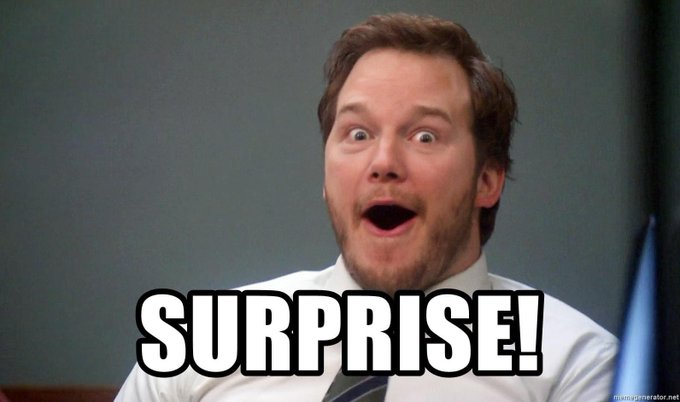

## 3. **¿Qué es lo que subirás a Kaggle?**

**Para subir a Kaggle la predicción esta tendrá que tener una forma específica.**

En este caso, la **MISMA** forma que `sample_submission.csv`. 

In [108]:
df_sample = pd.read_csv("data/sample_submission.csv")

In [109]:
df_sample.shape

(391, 2)

In [110]:
df_sample.head()

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6


## 4. Mete tus predicciones en un dataframe llamado ``submission``.

In [111]:
#¿Cómo creamos la submission?
submission = pd.DataFrame({
    'laptop_ID': df_test['laptop_ID'],
    'Price_in_euros': predictions
})

In [112]:
submission.head()

,laptop_ID,Price_in_euros
0,209,1467.061768
1,1281,322.963409
2,1168,336.660614
3,1231,1069.241211
4,1020,920.343079


In [113]:
submission.shape

(391, 2)

In [114]:
# Guardo el nuevo submission para subir
submission.to_csv("submission.csv", index=False)

## 5. Pásale el CHEQUEADOR para comprobar que efectivamente está listo para subir a Kaggle.

In [115]:
def chequeador(df_to_submit):
    """
    Esta función se asegura de que tu submission tenga la forma requerida por Kaggle.
    
    Si es así, se guardará el dataframe en un `csv` y estará listo para subir a Kaggle.
    
    Si no, LEE EL MENSAJE Y HAZLE CASO.
    
    Si aún no:
    - apaga tu ordenador, 
    - date una vuelta, 
    - enciendelo otra vez, 
    - abre este notebook y 
    - leelo todo de nuevo. 
    Todos nos merecemos una segunda oportunidad. También tú.
    """
    if df_to_submit.shape == df_sample.shape:
        if df_to_submit.columns.all() == df_sample.columns.all():
            if df_to_submit.laptop_ID.all() == df_sample.laptop_ID.all():
                print("You're ready to submit!")
                df_to_submit.to_csv("submission.csv", index = False) #muy importante el index = False
                urllib.request.urlretrieve("https://www.mihaileric.com/static/evaluation-meme-e0a350f278a36346e6d46b139b1d0da0-ed51e.jpg", "gfg.png")     
                img = Image.open("gfg.png")
                img.show()   
            else:
                print("Check the ids and try again")
        else:
            print("Check the names of the columns and try again")
    else:
        print("Check the number of rows and/or columns and try again")
        print("\nMensaje secreto del TA: No me puedo creer que después de todo este notebook hayas hecho algún cambio en las filas de `test.csv`. Lloro.")

In [116]:
# 4. Pasamos el chequeador oficial de clase (ahora que 'sample' ya está en memoria)
chequeador(submission)

You're ready to submit!
